## 4. Evaluation

### 4.1 Importing the Library

In [1]:
import pickle
import numpy as np
import os
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, accuracy_score
from tensorflow.keras.models import load_model
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

2025-11-17 11:49:34.262444: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2025-11-17 11:49:34.262808: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-11-17 11:49:34.311133: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-11-17 11:49:35.370675: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off,

In [2]:
DATA_DIR = "../dataset/processed/02_after_FE"
MODEL_DIR = "../models"

### 4.2 Load the Data

In [3]:
X_test_tfidf  = pickle.load(open(os.path.join(DATA_DIR, "X_test_tfidf.pkl"), "rb"))
X_test_pad    = pickle.load(open(os.path.join(DATA_DIR, "X_test_pad.pkl"), "rb"))
y_test        = pickle.load(open(os.path.join(DATA_DIR, "y_test.pkl"), "rb"))

### 4.3 Check Array Dimension

In [4]:
y_test_sklearn = y_test.astype(int).ravel()

### 4.4 Load Models

In [5]:
rf_model     = pickle.load(open(os.path.join(MODEL_DIR, "rf_model.pkl"), "rb"))
lstm_model   = load_model(os.path.join(MODEL_DIR, "lstm_model.keras"))
bilstm_model = load_model(os.path.join(MODEL_DIR, "bilstm_model.keras"))

E0000 00:00:1763354975.856223   87373 cuda_executor.cc:1309] INTERNAL: CUDA Runtime error: Failed call to cudaGetRuntimeVersion: Error loading CUDA libraries. GPU will not be used.: Error loading CUDA libraries. GPU will not be used.
W0000 00:00:1763354975.875055   87373 gpu_device.cc:2342] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


### 4.5 Evaluating Function

In [6]:
def evaluate_model(name, y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    print(f"Akurasi : {acc:.4f}")
    # y_true di sini harus y_test_sklearn
    print(classification_report(y_true, y_pred))
    return acc

### 4.6 Predicting and Evaluate All Models

In [7]:
def evaluate_model(name, y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)

    return {
        "accuracy": acc,
        "precision": prec,
        "recall": rec,
        "f1": f1
    }

def round_metrics(metrics_dict):
    return {k: round(v, 4) for k, v in metrics_dict.items()}


scores = {}

# Random Forest + TF-IDF 
rf_pred = rf_model.predict(X_test_tfidf)
scores['Random Forest (TF-IDF)'] = round_metrics(
    evaluate_model("Random Forest (TF-IDF)", y_test_sklearn, rf_pred)
)


# LSTM + TF-IDF 
lstm_pred_prob = lstm_model.predict([X_test_pad, X_test_tfidf])
lstm_pred = (lstm_pred_prob > 0.5).astype(int).ravel()
scores['LSTM + TF-IDF'] = round_metrics(
    evaluate_model("LSTM + TF-IDF", y_test_sklearn, lstm_pred)
)


# BiLSTM + TF-IDF
bilstm_pred_prob = bilstm_model.predict([X_test_pad, X_test_tfidf])
bilstm_pred = (bilstm_pred_prob > 0.5).astype(int).ravel()
scores['BiLSTM + TF-IDF'] = round_metrics(
    evaluate_model("BiLSTM + TF-IDF", y_test_sklearn, bilstm_pred)
)

for model_name, metrics in scores.items():
    print(f"\n-{model_name}-")
    for metric_name, value in metrics.items():
        print(f"{metric_name}: {value}")


[Parallel(n_jobs=22)]: Using backend ThreadingBackend with 22 concurrent workers.
[Parallel(n_jobs=22)]: Done   6 tasks      | elapsed:    0.0s
[Parallel(n_jobs=22)]: Done 100 out of 100 | elapsed:    0.1s finished


129/129 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step
129/129 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step

-Random Forest (TF-IDF)-
accuracy: 0.984
precision: 0.9664
recall: 0.8196
f1: 0.887

-LSTM + TF-IDF-
accuracy: 0.984
precision: 0.9252
recall: 0.8608
f1: 0.8918

-BiLSTM + TF-IDF-
accuracy: 0.9825
precision: 0.9178
recall: 0.8481
f1: 0.8816


In [8]:
scores

{'Random Forest (TF-IDF)': {'accuracy': 0.984,
  'precision': 0.9664,
  'recall': 0.8196,
  'f1': 0.887},
 'LSTM + TF-IDF': {'accuracy': 0.984,
  'precision': 0.9252,
  'recall': 0.8608,
  'f1': 0.8918},
 'BiLSTM + TF-IDF': {'accuracy': 0.9825,
  'precision': 0.9178,
  'recall': 0.8481,
  'f1': 0.8816}}

### 4.7 Visualizing

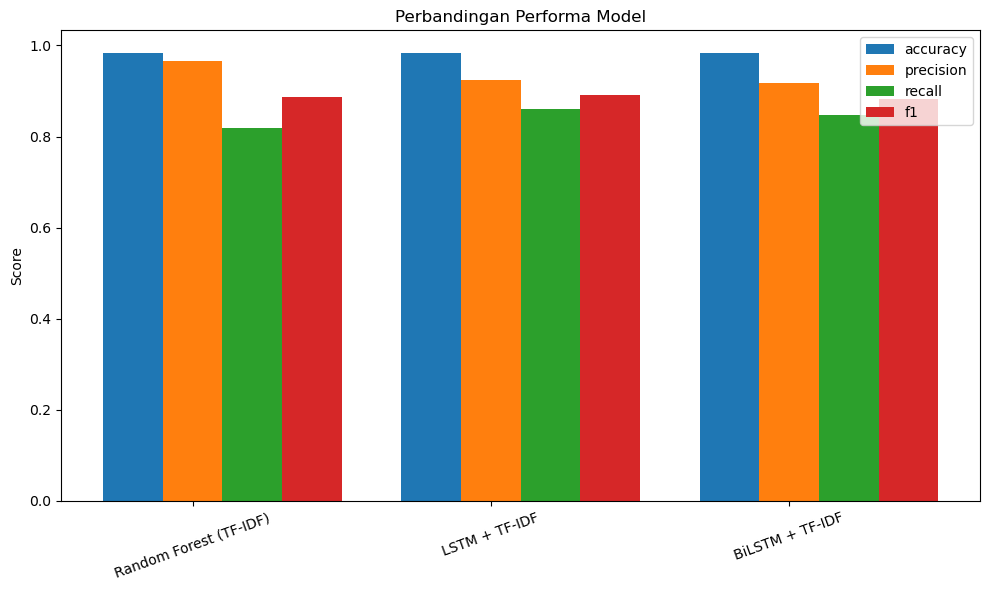

In [9]:
models = list(scores.keys())
metrics = ["accuracy", "precision", "recall", "f1"]

values = np.array([[scores[m][metric] for metric in metrics] for m in models])

x = np.arange(len(models))
width = 0.2

plt.figure(figsize=(10, 6))

for i, metric in enumerate(metrics):
    plt.bar(x + i*width, values[:, i], width, label=metric)

plt.xticks(x + width, models, rotation=20)
plt.ylabel("Score")
plt.title("Perbandingan Performa Model")
plt.legend()
plt.tight_layout()
plt.show()
